In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

In [ ]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Define the project path
PROJECT_PATH = Path('/content/drive/MyDrive/AutomaticHeartSoundClassification-main')
sys.path.append(str(PROJECT_PATH))

# Define the dataset path
DATASET_PATH = Path('/content/drive/MyDrive/physionet2016')

mfcc_folder   = PROJECT_PATH / "mfcc_features"

In [ ]:
N_MFCC = 39
T_FIXED = 333



```
<base>/
├── annotations/
├── papers/
├── sources/
├── training-a/
├── training-b/
├── training-c/
├── training-d/
├── training-e/
├── training-f/
├── validation/
├── training.zip
├── validation.zip
└── README / figure / sample files
```






```
training-a/
├── a0001.wav
├── a0001.hea
├── a0001.dat
├── a0002.wav
├── a0002.hea
├── a0002.dat
├── ...
├── REFERENCE.csv
├── REFERENCE-SQI.csv
├── RECORDS
├── RECORDS-normal
├── RECORDS-abnormal
├── MD5SUMS / SHA1SUMS / SHA256SUMS
```



In [ ]:
import numpy as np
import pandas as pd
import librosa
from tqdm import tqdm
import soundfile
import h5py
import random
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, Sampler, DataLoader
import json
import torch
import librosa
from pathlib import Path
from itertools import repeat
from collections import OrderedDict
from scipy.signal import butter, lfilter
from sklearn.model_selection import train_test_split
import glob
import os
from collections import Counter

import librosa

In [ ]:
wav_files = glob.glob("/content/drive/MyDrive/physionet2016/training-*/*.wav")

normal_files = []
abnormal_files = []

for f in wav_files:
    hea_file = f.replace(".wav", ".hea")
    if os.path.exists(hea_file):
        with open(hea_file, "r") as hf:
            for line in hf:
                line = line.strip().lower()
                if line.startswith("# normal"):
                    normal_files.append(f)
                    break
                elif line.startswith("# abnormal"):
                    abnormal_files.append(f)
                    break

print("Tổng số file:", len(wav_files))
print("Normal:", len(normal_files))
print("Abnormal:", len(abnormal_files))

Tổng số file: 3240
Normal: 2575
Abnormal: 665


# Đọc audio & tiền xử lý tín hiệu

In [ ]:
lowcut = 20      # Hz
highcut = 600    # Hz
fs = 2000        # Hz
order = 4

In [ ]:
def read_audio(path, target_fs=None, filter=False,
               lowcut=lowcut, hightcut=highcut):
    (audio, fs) = soundfile.read(path)

    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    if target_fs is not None and fs != target_fs:
        audio = librosa.resample(audio, orig_sr = fs, target_sr = target_fs)
        fs = target_fs
    if filter:
        # apply bandpass filter
        audio = butter_bandpass_filter(audio, lowcut, hightcut, fs, order)
    return audio, fs

In [ ]:
def butter_bandpass(lowcut, hightcut, fs, order=order):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = hightcut / nyq
    b, a = butter(order, [low, high], btype='bandpass')
    return b, a

def butter_bandpass_filter(data, lowcut, hightcut, fs, order):
    b, a = butter_bandpass(lowcut, hightcut, fs, order=order)
    y = lfilter(b, a, data)
    return y

In [ ]:
'''
def augment_audio(audio, fs):
    """Apply random augmentations to audio signal."""
    if random.random() < 0.5:
        # Add Gaussian noise
        noise = np.random.normal(0, 0.01 * np.std(audio), len(audio))
        audio += noise

    if random.random() < 0.5:
        # Time shift (roll)
        shift = random.randint(-len(audio)//10, len(audio)//10)
        audio = np.roll(audio, shift)

    if random.random() < 0.5:
        # Pitch shift
        n_steps = random.uniform(-2, 2)
        audio = librosa.effects.pitch_shift(audio, sr=fs, n_steps=n_steps)

    if random.random() < 0.5:
        # Time stretch
        rate = random.uniform(0.8, 1.2)
        audio = librosa.effects.time_stretch(audio, rate=rate)

    if random.random() < 0.2:
        # Polarity inversion
        audio = -audio

    return audio
'''

'\ndef augment_audio(audio, fs):\n    """Apply random augmentations to audio signal."""\n    if random.random() < 0.5:\n        # Add Gaussian noise\n        noise = np.random.normal(0, 0.01 * np.std(audio), len(audio))\n        audio += noise\n\n    if random.random() < 0.5:\n        # Time shift (roll)\n        shift = random.randint(-len(audio)//10, len(audio)//10)\n        audio = np.roll(audio, shift)\n\n    if random.random() < 0.5:\n        # Pitch shift\n        n_steps = random.uniform(-2, 2)\n        audio = librosa.effects.pitch_shift(audio, sr=fs, n_steps=n_steps)\n\n    if random.random() < 0.5:\n        # Time stretch\n        rate = random.uniform(0.8, 1.2)\n        audio = librosa.effects.time_stretch(audio, rate=rate)\n\n    if random.random() < 0.2:\n        # Polarity inversion\n        audio = -audio\n\n    return audio\n'

In [ ]:
import numpy as np
import random
import librosa

def augment_audio(audio, fs, label=None):
    """
    Data augmentation for PCG signals based on PhysioNet 2016 setting.

    Augmentations are preferentially applied to the abnormal class
    to mitigate class imbalance.

    Parameters
    ----------
    audio : np.ndarray
        Input PCG signal
    fs : int
        Sampling frequency (Hz), typically 2000
    label : int or None
        Class label (0: normal, 1: abnormal)

    Returns
    -------
    audio_aug : np.ndarray
        Augmented audio signal
    """

    audio_aug = audio.copy()

    # Only apply augmentation aggressively to abnormal class
    if label == 1 and random.random() < 0.5:

        # 1. Additive Gaussian noise (α = 0.005)
        if random.random() < 0.5:
            noise = np.random.normal(
                0,
                0.005 * np.std(audio_aug),
                size=len(audio_aug)
            )
            audio_aug = audio_aug + noise

        # 2. Time shift (Δ = ±0.05 * fs = ±100 samples)
        if random.random() < 0.5:
            shift = random.randint(-int(0.05 * fs), int(0.05 * fs))
            audio_aug = np.roll(audio_aug, shift)
            if shift > 0:
                audio_aug[:shift] = 0
            elif shift < 0:
                audio_aug[shift:] = 0

        # 3. Pitch shift (−2 to +2 semitones)
        if random.random() < 0.5:
            n_steps = random.uniform(-2, 2)
            audio_aug = librosa.effects.pitch_shift(
                audio_aug,
                sr=fs,
                n_steps=n_steps
            )

    return audio_aug

## Test

In [ ]:
def compute_fft(signal, fs):
    """
    Compute single-sided amplitude spectrum.
    """
    N = len(signal)
    fft_vals = np.fft.rfft(signal)
    fft_mag = np.abs(fft_vals) / N
    freqs = np.fft.rfftfreq(N, d=1/fs)
    return freqs, fft_mag

In [ ]:
normal_file = Path(DATASET_PATH/'training-a/a0007.wav')
abnormal_file = Path(DATASET_PATH/'training-a/a0001.wav')

Normal

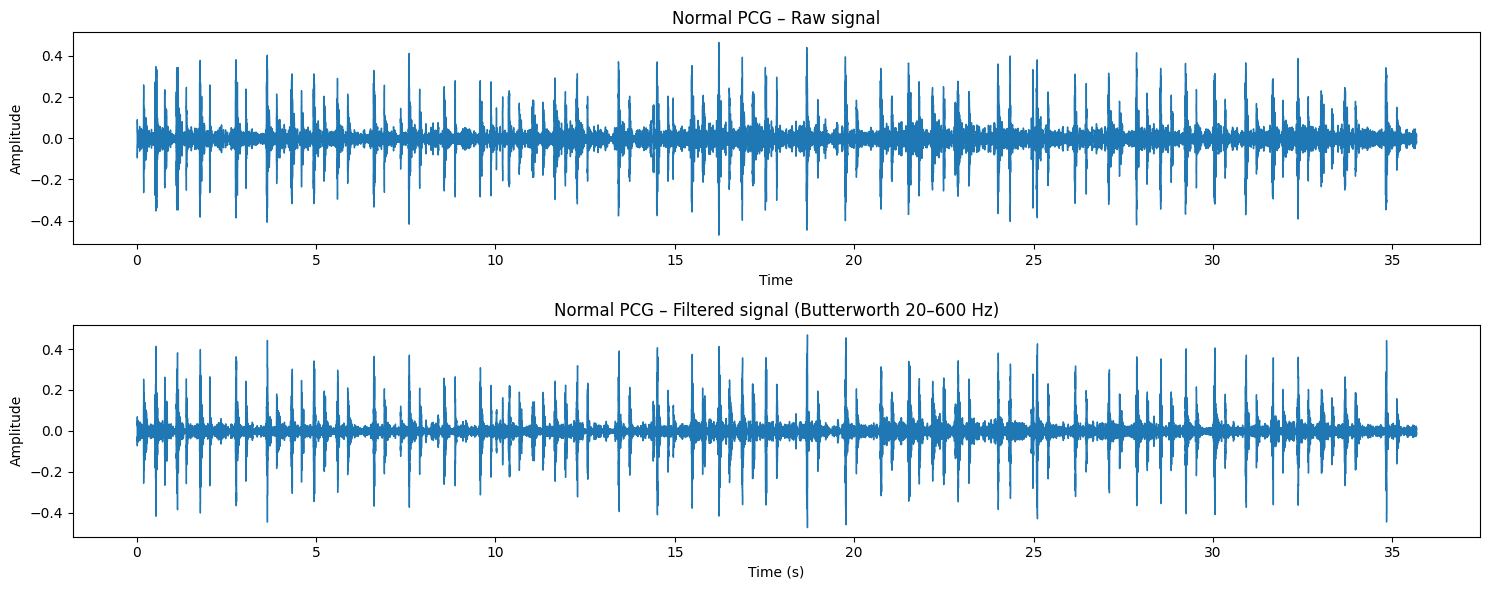

In [ ]:
#Miền thời gian
audio_normal_raw, fs = read_audio(str(normal_file), filter=False)
audio_normal_filt, _ = read_audio(str(normal_file), filter=True)

plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
librosa.display.waveshow(audio_normal_raw, sr=fs)
plt.title("Normal PCG – Raw signal")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)
librosa.display.waveshow(audio_normal_filt, sr=fs)
plt.title("Normal PCG – Filtered signal (Butterworth 20–600 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


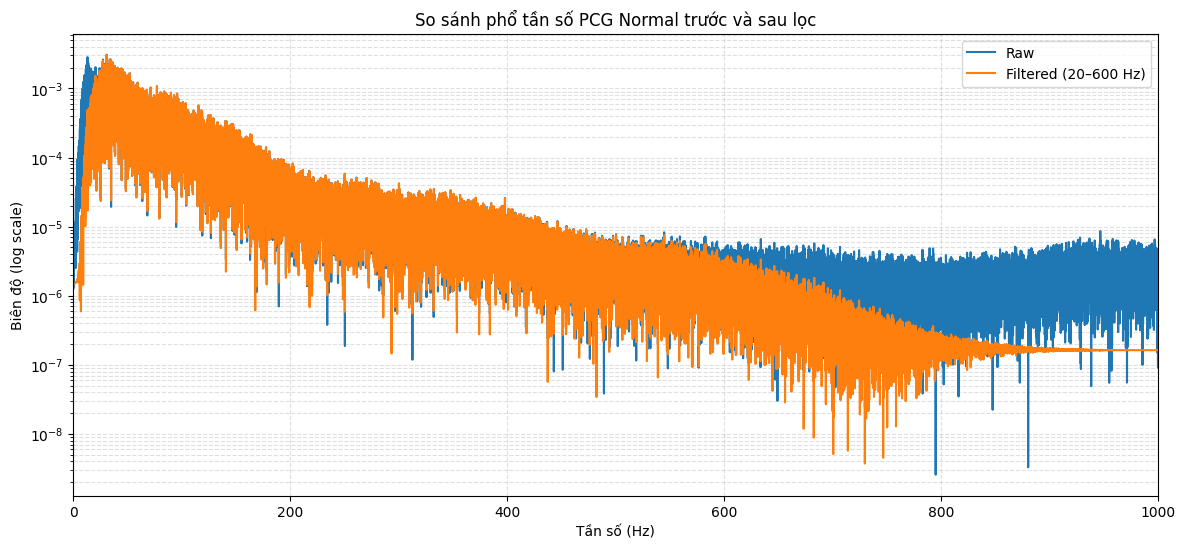

In [ ]:
# Miền tần số
freqs_raw, fft_raw = compute_fft(audio_normal_raw, fs)
freqs_filt, fft_filt = compute_fft(audio_normal_filt, fs)

plt.figure(figsize=(14, 6))
plt.semilogy(freqs_raw, fft_raw, label="Raw")
plt.semilogy(freqs_filt, fft_filt, label="Filtered (20–600 Hz)")

plt.xlim(0, 1000)
plt.title("So sánh phổ tần số PCG Normal trước và sau lọc")
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ (log scale)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()


Abnormal

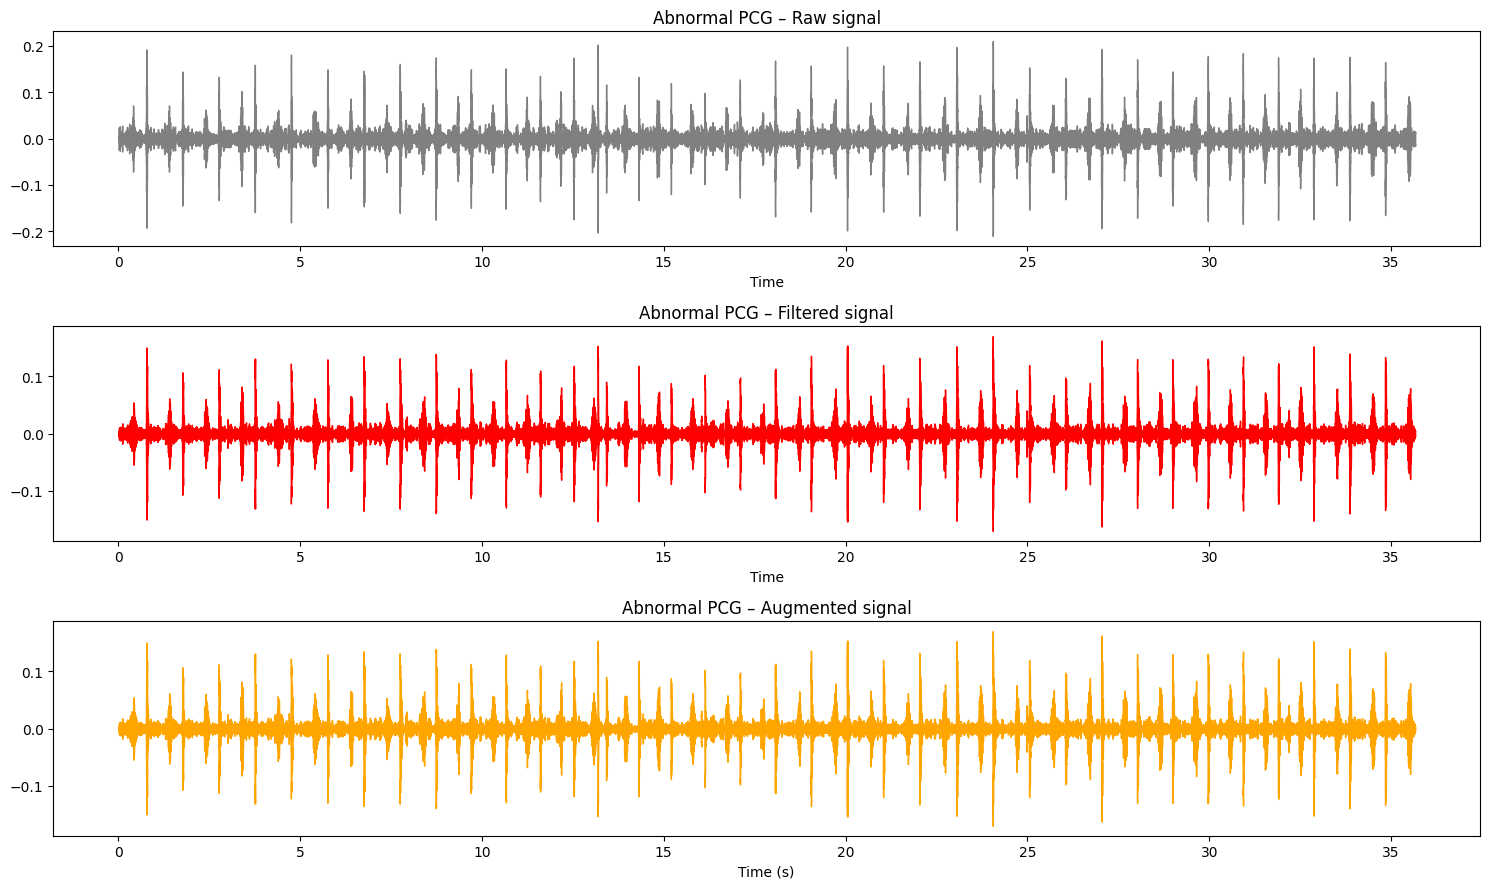

In [ ]:
#Miền thời gian
audio_abnormal_raw, fs = read_audio(str(abnormal_file), filter=False)
audio_abnormal_filt, _ = read_audio(str(abnormal_file), filter=True)
audio_abnormal_aug = augment_audio(audio_abnormal_filt, fs, label=1)

plt.figure(figsize=(15, 9))

plt.subplot(3, 1, 1)
librosa.display.waveshow(audio_abnormal_raw, sr=fs, color="gray")
plt.title("Abnormal PCG – Raw signal")

plt.subplot(3, 1, 2)
librosa.display.waveshow(audio_abnormal_filt, sr=fs, color="red")
plt.title("Abnormal PCG – Filtered signal")

plt.subplot(3, 1, 3)
librosa.display.waveshow(audio_abnormal_aug, sr=fs, color="orange")
plt.title("Abnormal PCG – Augmented signal")

plt.xlabel("Time (s)")
plt.tight_layout()
plt.show()


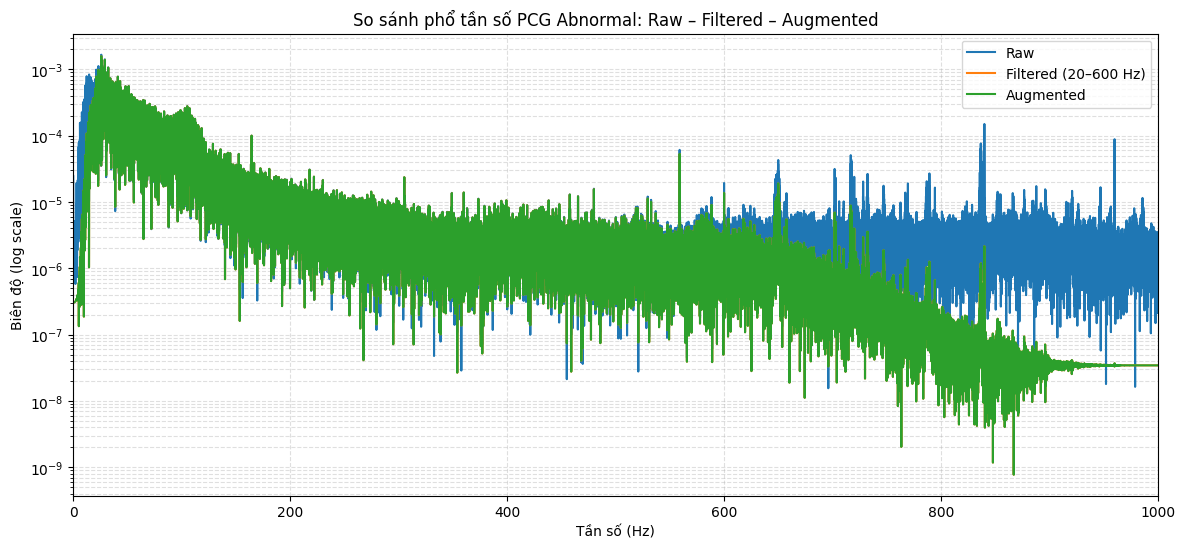

In [ ]:
#Miền tần số
freqs_raw, fft_raw = compute_fft(audio_abnormal_raw, fs)
freqs_filt, fft_filt = compute_fft(audio_abnormal_filt, fs)
freqs_aug, fft_aug = compute_fft(audio_abnormal_aug, fs)

plt.figure(figsize=(14, 6))
plt.semilogy(freqs_raw, fft_raw, label="Raw")
plt.semilogy(freqs_filt, fft_filt, label="Filtered (20–600 Hz)")
plt.semilogy(freqs_aug, fft_aug, label="Augmented")

plt.xlim(0, 1000)
plt.title("So sánh phổ tần số PCG Abnormal: Raw – Filtered – Augmented")
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ (log scale)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.show()


# MFCC Extractor



*   data: mảng chứa tín hiệu âm thanh (waveform) đã đọc từ file .wav.
*   sr: tần số lấy mẫu (sampling rate).
*   n_mfcc: số hệ số MFCC mong muốn (thường 13 hoặc 39).
*   window: loại cửa sổ áp dụng khi phân khung (ở đây là Hamming).
*   hoplen: bước dịch giữa các khung (ms).
*   winlen: độ dài mỗi khung (ms).
*   T_fixed: số khung thời gian cố định sau khi chuẩn hóa.
*   snv: có chuẩn hóa SNV hay không.







In [ ]:
import numpy as np
import librosa

import numpy as np
import librosa

def MfccExtractor(
    data,
    sr,
    n_mfcc=N_MFCC,
    window='hamming',
    hoplen=15,   # ms
    winlen=25,   # ms
    T_fixed= T_FIXED, # Đã tăng lên theo đề xuất (5s / 15ms ~ 333)
    snv=False
):
    """
    MFCC extraction pipeline following Viet Hung thesis:
    - Full signal MFCC
    - Temporal truncation / zero-padding to fixed T
    """

    MFCC_ARGS = {
        'sr': sr,
        'window': window,
        'hop_length': int(sr * hoplen / 1000),
        'win_length': int(sr * winlen / 1000),
    }

    if n_mfcc == 39:
        # Nếu muốn 39, ta trích xuất 13 hệ số tĩnh rồi tính thêm Delta/Delta-Delta (13*3=39)
        mfcc_static = librosa.feature.mfcc(y=data, n_mfcc=13, **MFCC_ARGS)
        delta = librosa.feature.delta(mfcc_static)
        delta2 = librosa.feature.delta(mfcc_static, order=2)
        mfcc = np.concatenate((mfcc_static, delta, delta2), axis=0) # Kết quả: (39, T)
    else:
        # Nếu config 13 (hoặc số khác), chỉ lấy hệ số tĩnh (Static)
        mfcc = librosa.feature.mfcc(y=data, n_mfcc=n_mfcc, **MFCC_ARGS) # Kết quả: (n_mfcc, T)

    if snv:
        mfcc = standard_normal_variate(mfcc)

    # ===== Temporal normalization (KEY STEP) =====
    T = mfcc.shape[1]

    if T >= T_fixed:
        mfcc = mfcc[:, :T_fixed]          # truncation
    else:
        pad = T_fixed - T
        mfcc = np.pad(
            mfcc,
            ((0, 0), (0, pad)),
            mode="wrap"
        )

    return mfcc.astype(np.float32)  # (39, 333)

In [ ]:
EPS = 1E-8
def LogMelExtractor(
    data,
    sr,
    mel_bins=128,
    hoplen=15,
    winlen=25,
    log=True,
    snv=False
):
    """
    Log-Mel spectrogram extractor
    """

    hop_length = int(sr * hoplen / 1000)
    win_length = int(sr * winlen / 1000)

    mel = librosa.feature.melspectrogram(
        y=data,
        sr=sr,
        n_mels=mel_bins,
        hop_length=hop_length,
        win_length=win_length
    )

    if log:
        mel = np.log(mel + EPS)

    if snv:
        mel = standard_normal_variate(mel)

    return mel.astype(np.float32)

In [ ]:
def standard_normal_variate(data):
    mean = np.mean(data)
    std = np.std(data)

    return (data - mean) / std

In [ ]:
data_processing_path = Path(PROJECT_PATH) / 'data_processing'
data_processing_path.mkdir(parents=True, exist_ok=True)

In [ ]:
import pandas as pd
import os
import sys
from pathlib import Path
from tqdm import tqdm  # Included as in original, though not used here

# Define the training folders based on the provided dataset structure
folders = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']

# Collect labels from each folder's REFERENCE.csv
dfs = []
for folder in folders:
    ref_path = DATASET_PATH / folder / 'REFERENCE.csv'
    df = pd.read_csv(ref_path, header=None, names=['basename', 'label'])

    # Correct way to create full filenames
    df['filename'] = [str(DATASET_PATH / folder / (base + '.wav')) for base in df['basename']]

    # Convert labels: -1 → 0, 1 → 1 (or abnormal → 1)
    df['label'] = (df['label'] + 1) // 2

    dfs.append(df[['filename', 'label']])

# Concatenate all dataframes and save to label.csv
all_df = pd.concat(dfs, ignore_index=True)
save_path = PROJECT_PATH / 'data' / 'label.csv'
save_dir = save_path.parent
os.makedirs(str(save_dir), exist_ok=True)
all_df.to_csv(str(save_path), index=False)

print(f"Created {str(save_path)} with {len(all_df)} entries.")

Created /content/drive/MyDrive/AutomaticHeartSoundClassification-main/data/label.csv with 3240 entries.


In [ ]:
print(type(df['filename']))
print(df['filename'].head(10))
print(repr(df['filename'].iloc[0]))
print("First element type:", type(df['filename'].iloc[0]) if len(df) > 0 else "empty")

<class 'pandas.core.series.Series'>
0    /content/drive/MyDrive/physionet2016/training-...
1    /content/drive/MyDrive/physionet2016/training-...
2    /content/drive/MyDrive/physionet2016/training-...
3    /content/drive/MyDrive/physionet2016/training-...
4    /content/drive/MyDrive/physionet2016/training-...
5    /content/drive/MyDrive/physionet2016/training-...
6    /content/drive/MyDrive/physionet2016/training-...
7    /content/drive/MyDrive/physionet2016/training-...
8    /content/drive/MyDrive/physionet2016/training-...
9    /content/drive/MyDrive/physionet2016/training-...
Name: filename, dtype: object
'/content/drive/MyDrive/physionet2016/training-f/f0001.wav'
First element type: <class 'str'>


In [ ]:
def npy_to_h5(label_csv, npy_folder, output_h5):
    """Chỉ pack các file có trong label_csv vào HDF5 — không lấy _aug."""
    df = pd.read_csv(label_csv)
    keys_wanted = set(df['filename'].apply(lambda x: Path(x).stem))

    if Path(output_h5).exists():
        print(f"⚠️  {Path(output_h5).name} đã tồn tại — xóa để tạo lại.")
        Path(output_h5).unlink()

    with h5py.File(output_h5, 'w') as h5f:
        for key in tqdm(keys_wanted, desc=f"Packing {Path(output_h5).name}"):
            npy_path = Path(npy_folder) / f"{key}.npy"
            if not npy_path.exists():
                print(f"Missing: {npy_path.name}")
                continue
            data = np.load(npy_path)
            h5f.create_dataset(key, data=data.astype(np.float32), compression="gzip")

    print(f"✅ {Path(output_h5).name}: {len(keys_wanted)} samples")

In [ ]:
def process_and_save(row, output_suffix="", is_augment=False):
    filename = row["filename"]
    label = row["label"]
    basename = Path(filename).stem + output_suffix

    # 1. Đọc audio
    audio, fs_val = read_audio(filename, filter=True)

    # 2. Nếu là augment, thực hiện biến đổi
    if is_augment:
        audio = augment_audio(audio, fs_val, label=label)

    # 3. Trích xuất MFCC
    mfcc = MfccExtractor(audio, fs_val, n_mfcc=N_MFCC, T_fixed=T_FIXED)

    # 4. Lưu file
    save_name = f"{basename}.npy"
    np.save(mfcc_folder / save_name, mfcc)

    return {"filename": basename, "label": label}

In [ ]:
import os
import numpy as np
import pandas as pd

from tqdm import tqdm
from collections import Counter
from pathlib import Path

# =========================
# read_audio()
# augment_audio()
# PROJECT_PATH
# MfccExtractor()
# LogMelExtractor()
# =========================

if __name__ == "__main__":

    df = pd.read_csv(PROJECT_PATH / "data" / "label.csv")
    df['base_id'] = df['filename'].apply(lambda x: Path(x).stem)

    # Split đảm bảo không leak bệnh nhân
    train_ids, val_ids = train_test_split(
        df['base_id'].unique(), test_size=0.2, random_state=42,
        stratify=df.drop_duplicates('base_id')['label']
    )
    df_train = df[df['base_id'].isin(train_ids)]
    df_val = df[df['base_id'].isin(val_ids)]

    # 2. Xử lý tập TRAIN (Gốc + Augment cho Abnormal)
    train_records = []
    for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Processing Train"):
        # Lưu file gốc
        train_records.append(process_and_save(row))
        # Augment riêng cho lớp 1 (Abnormal) để cân bằng
        if row['label'] == 1:
            for i in range(3):
                train_records.append(process_and_save(row, output_suffix=f"_aug{i}", is_augment=True))

    # 3. Xử lý tập VAL (Chỉ file gốc)
    val_records = []
    for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Processing Val"):
        val_records.append(process_and_save(row))

    # 4. Lưu các file CSV label mới
    df_train_aug = pd.DataFrame(train_records)
    df_val_clean = pd.DataFrame(val_records)
    df_train_aug.to_csv(PROJECT_PATH / "data" / "label_train_augmented.csv", index=False)
    df_val_clean.to_csv(PROJECT_PATH / "data" / "label_val_clean.csv", index=False)

    # 5. Đóng gói vào HDF5 (Sử dụng CSV ĐÃ AUGMENT)
    npy_to_h5(
        label_csv = PROJECT_PATH / "data" / "label_train_augmented.csv", # QUAN TRỌNG: Dùng file này
        npy_folder = mfcc_folder,
        output_h5 = PROJECT_PATH / "data" / "mfcc_train.h5"
    )
    npy_to_h5(
        label_csv = PROJECT_PATH / "data" / "label_val_clean.csv",
        npy_folder = mfcc_folder,
        output_h5 = PROJECT_PATH / "data" / "mfcc_val_internal.h5"
    )


Processing Val: 100%|██████████| 648/648 [12:13<00:00,  1.13s/it]


⚠️  mfcc_train.h5 đã tồn tại — xóa để tạo lại.


Packing mfcc_train.h5: 100%|██████████| 4188/4188 [00:50<00:00, 82.27it/s]


✅ mfcc_train.h5: 4188 samples
⚠️  mfcc_val_internal.h5 đã tồn tại — xóa để tạo lại.


Packing mfcc_val_internal.h5: 100%|██████████| 648/648 [00:06<00:00, 92.94it/s]


✅ mfcc_val_internal.h5: 648 samples


In [ ]:
logmel_folder = PROJECT_PATH / "logmel_features"
mfcc_folder   = PROJECT_PATH / "mfcc_features"

label_counts = Counter(df["label"])
print(f"[PhysioNet Val — natural distribution]")
print(f"  Normal: {label_counts[0]} | Abnormal: {label_counts[1]}")
print(f"  (Giữ nguyên imbalance — phản ánh phân phối lâm sàng thực tế)")

[PhysioNet Val — natural distribution]
  Normal: 2575 | Abnormal: 665
  (Giữ nguyên imbalance — phản ánh phân phối lâm sàng thực tế)


In [ ]:
from sklearn.model_selection import train_test_split

# 1. Lưu label_clean.csv — chỉ original, không _aug
df.to_csv(PROJECT_PATH / "data" / "label_clean.csv", index=False)
print("✅ label_clean.csv saved")

# 2. Patient-level stratified split
df['base_id'] = df['filename'].apply(lambda x: Path(x).stem)
id_label = df.drop_duplicates('base_id').set_index('base_id')['label']
unique_ids = id_label.index.values

train_ids, val_ids = train_test_split(
    unique_ids,
    test_size=0.2,
    random_state=42,
    stratify=id_label.loc[unique_ids].values  # giữ tỷ lệ class đồng đều
)

#df_train = df[df['base_id'].isin(train_ids)]
#df_val   = df[df['base_id'].isin(val_ids)]

df_train = df[df['base_id'].isin(train_ids)].copy()
df_val_raw = df[df['base_id'].isin(val_ids)].copy()

n_val_normal   = (df_val_raw['label'] == 0).sum()
n_val_abnormal = (df_val_raw['label'] == 1).sum()
n_val_min      = min(n_val_normal, n_val_abnormal)

print(f"Val trước khi cân bằng: Normal={n_val_normal}, Abnormal={n_val_abnormal}")

df_val = pd.concat([
    df_val_raw[df_val_raw['label'] == 0].sample(n=n_val_min, random_state=42),
    df_val_raw[df_val_raw['label'] == 1].sample(n=n_val_min, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Val sau khi cân bằng : Normal={n_val_min}, Abnormal={n_val_min}")

df_train.to_csv(PROJECT_PATH / "data" / "label_train.csv",        index=False)
df_val.to_csv(  PROJECT_PATH / "data" / "label_val_internal.csv", index=False)

print(f"Train: {len(df_train)} | Normal={( df_train['label']==0).sum()} | Abnormal={(df_train['label']==1).sum()}")
print(f"Val  : {len(df_val)}   | Normal={(df_val['label']==0).sum()}   | Abnormal={(df_val['label']==1).sum()}")

train_base = set(df_train['filename'].apply(lambda x: Path(x).stem))
val_base   = set(df_val['filename'].apply(lambda x: Path(x).stem))
assert len(train_base & val_base) == 0, "BUG: Patient overlap!"
print("✅ No patient overlap between train and val")

✅ label_clean.csv saved
Val trước khi cân bằng: Normal=515, Abnormal=133
Val sau khi cân bằng : Normal=133, Abnormal=133
Train: 2592 | Normal=2060 | Abnormal=532
Val  : 266   | Normal=133   | Abnormal=133
✅ No patient overlap between train and val


In [ ]:
train_records = []
for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="Processing Train"):
    # Lưu bản gốc
    train_records.append(process_and_save(row))

    # Nếu là Abnormal, tạo thêm 3 bản augment (ví dụ số lượng là 3)
    if row['label'] == 1:
        for i in range(3):
            train_records.append(process_and_save(row, output_suffix=f"_aug{i}", is_augment=True))

# --- THỰC THI TRÊN TẬP VAL ---
val_records = []
for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Processing Val"):
    # Val KHÔNG augment
    val_records.append(process_and_save(row))

# Lưu lại label mới đã bao gồm các file augment
pd.DataFrame(train_records).to_csv(PROJECT_PATH / "data" / "label_train_augmented.csv", index=False)
pd.DataFrame(val_records).to_csv(PROJECT_PATH / "data" / "label_val_clean.csv", index=False)

Processing Val: 100%|██████████| 266/266 [00:41<00:00,  6.45it/s]


In [ ]:
df_train_aug = pd.DataFrame(train_records)
df_val_clean = pd.DataFrame(val_records)
df_train_aug.to_csv(PROJECT_PATH / "data" / "label_train_augmented.csv", index=False)
df_val_clean.to_csv(PROJECT_PATH / "data" / "label_val_clean.csv",       index=False)

print(f"Train sau Augment: {len(df_train_aug)} | "
      f"Normal={(df_train_aug['label']==0).sum()} | "
      f"Abnormal={(df_train_aug['label']==1).sum()}")
print(f"Val: {len(df_val_clean)} | "
      f"Normal={(df_val_clean['label']==0).sum()} | "
      f"Abnormal={(df_val_clean['label']==1).sum()}")

# Leak check lần 2 (sau augment)
train_aug_base = set(df_train_aug['filename'].apply(lambda x: str(x).split('_aug')[0]))
val_clean_base = set(df_val_clean['filename'].apply(lambda x: str(x)))
assert len(train_aug_base & val_clean_base) == 0, "BUG: Patient overlap after augment!"
print("✅ No patient overlap after augmentation")

Train sau Augment: 4188 | Normal=2060 | Abnormal=2128
Val: 266 | Normal=133 | Abnormal=133
✅ No patient overlap after augmentation


In [ ]:
npy_to_h5(
    label_csv  = PROJECT_PATH / "data" / "label_train_augmented.csv",
    npy_folder = mfcc_folder,
    output_h5  = PROJECT_PATH / "data" / "mfcc_train.h5"
)
npy_to_h5(
    label_csv  = PROJECT_PATH / "data" / "label_val_clean.csv",
    npy_folder = mfcc_folder,
    output_h5  = PROJECT_PATH / "data" / "mfcc_val_internal.h5"
)
print("✅ HDF5 files created successfully")

⚠️  mfcc_train.h5 đã tồn tại — xóa để tạo lại.


Packing mfcc_train.h5: 100%|██████████| 4188/4188 [01:01<00:00, 67.92it/s]


✅ mfcc_train.h5: 4188 samples
⚠️  mfcc_val_internal.h5 đã tồn tại — xóa để tạo lại.


Packing mfcc_val_internal.h5: 100%|██████████| 266/266 [00:03<00:00, 80.51it/s]


✅ mfcc_val_internal.h5: 266 samples
✅ HDF5 files created successfully


# Test file

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

# Root dataset PhysioNet 2016
original_audio_root = Path("/content/drive/MyDrive/physionet2016")

logmel_folder = Path(logmel_folder)
mfcc_folder   = Path(mfcc_folder)

## Normal

[NORMAL] Audio path: /content/drive/MyDrive/physionet2016/training-a/a0007.wav
[NORMAL] Length: 71332 | Duration: 35.67s | SR: 2000
[NORMAL] MFCC shape: (39, 333)


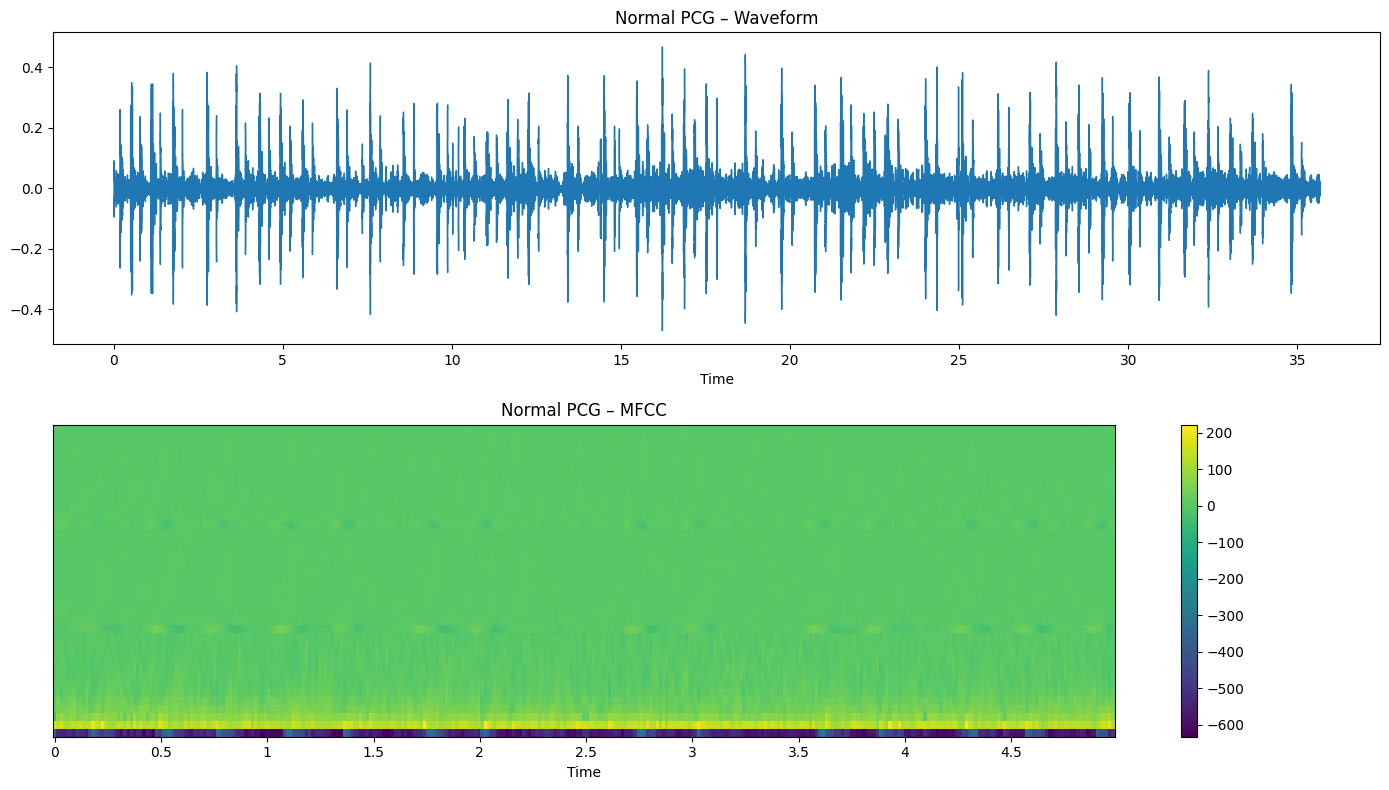

In [ ]:
# ========================
# NORMAL SAMPLE
# ========================

normal_file = Path(normal_file)          # ví dụ: a0007.wav
normal_basename = normal_file.stem        # a0007
folder_letter = normal_basename[0]

wav_path = original_audio_root / f"training-{folder_letter}" / normal_file.name
print(f"[NORMAL] Audio path: {wav_path}")

# 1. Load raw audio
audio_norm, sr = librosa.load(wav_path, sr=None)
print(f"[NORMAL] Length: {len(audio_norm)} | Duration: {len(audio_norm)/sr:.2f}s | SR: {sr}")

# 3. Load MFCC
mfcc_norm = np.load(mfcc_folder / f"{normal_basename}.npy")
print(f"[NORMAL] MFCC shape: {mfcc_norm.shape}")

# 4. Visualization
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)
librosa.display.waveshow(audio_norm, sr=sr)
plt.title("Normal PCG – Waveform")

plt.subplot(2, 1, 2)
librosa.display.specshow(
    mfcc_norm,
    sr=sr,
    hop_length=int(sr * 15 / 1000),
    x_axis='time',
    cmap='viridis'
)
plt.colorbar()
plt.title("Normal PCG – MFCC")

plt.tight_layout()
plt.show()

## Abnormal

[ABNORMAL] Audio path: /content/drive/MyDrive/physionet2016/training-a/a0001.wav
[ABNORMAL] Length: 71332 | Duration: 35.67s | SR: 2000
[ABNORMAL] MFCC original shape : (39, 333)


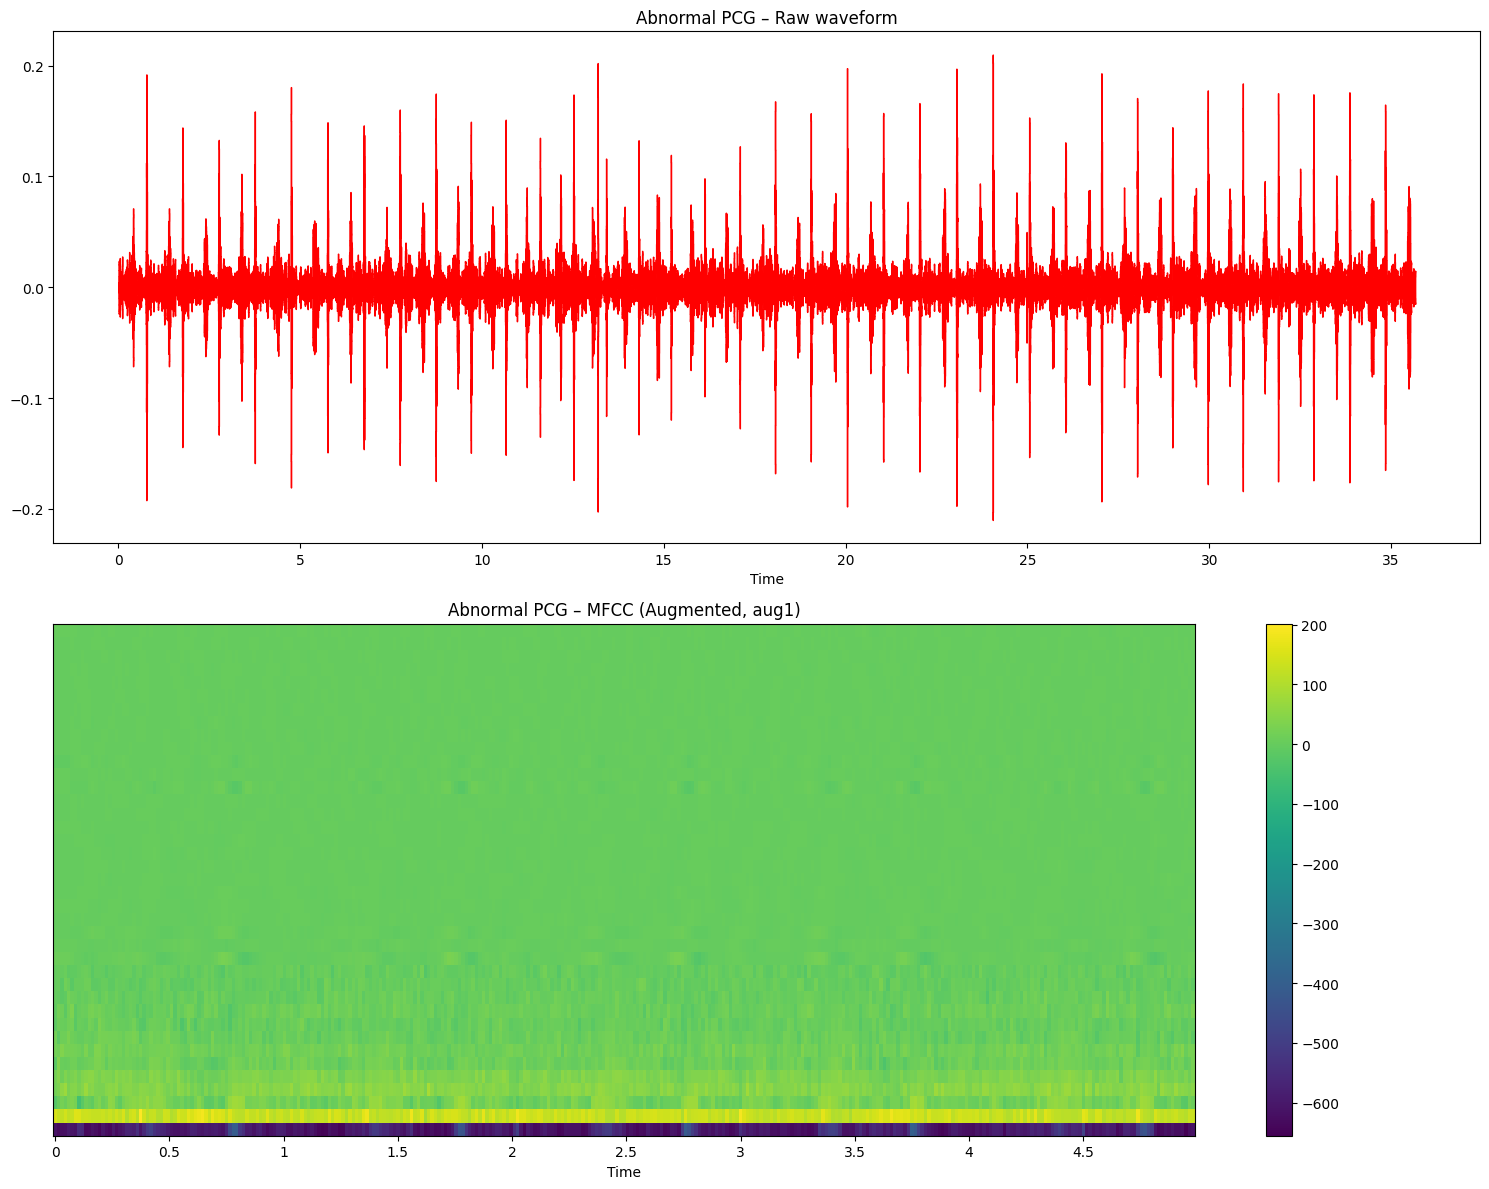

In [ ]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path

# ========================
# ABNORMAL SAMPLE (RAW + AUGMENTED)
# ========================

abnormal_file = Path(abnormal_file)          # ví dụ: a0077.wav hoặc a0001.wav
abnormal_basename = abnormal_file.stem        # a0077
folder_letter = abnormal_basename[0]

wav_path = original_audio_root / f"training-{folder_letter}" / abnormal_file.name
print(f"[ABNORMAL] Audio path: {wav_path}")

# 1. Load raw abnormal audio
audio_abn, sr = librosa.load(wav_path, sr=None)
print(f"[ABNORMAL] Length: {len(audio_abn)} | Duration: {len(audio_abn)/sr:.2f}s | SR: {sr}")

# 2. Load original features
#logmel_abn = np.load(logmel_folder / f"{abnormal_basename}.npy")
mfcc_abn   = np.load(mfcc_folder / f"{abnormal_basename}.npy")

print(f"[ABNORMAL] MFCC original shape : {mfcc_abn.shape}")

# 3. Load augmented features (aug0, aug1, aug2)
#aug_logmels = []
aug_mfccs   = []

for i in range(3):
    aug_name = f"{abnormal_basename}_aug{i}.npy"

    #logmel_aug = np.load(logmel_folder / aug_name)
    mfcc_aug   = np.load(mfcc_folder / aug_name)

    #aug_logmels.append(logmel_aug)
    aug_mfccs.append(mfcc_aug)


# ========================
# Visualization
# ========================

plt.figure(figsize=(15, 12))

# (1) Waveform (raw)
plt.subplot(2, 1, 1)
librosa.display.waveshow(audio_abn, sr=sr, color="red")
plt.title("Abnormal PCG – Raw waveform")

# (4) MFCC augmented (ví dụ aug1)
plt.subplot(2, 1, 2)
librosa.display.specshow(
    aug_mfccs[1],
    sr=sr,
    hop_length=int(sr * 15 / 1000),
    x_axis="time",
    cmap="viridis"
)
plt.colorbar()
plt.title("Abnormal PCG – MFCC (Augmented, aug1)")

plt.tight_layout()
plt.show()

## Create .h5py for MFCC

## Create .nqz for MFCC

In [ ]:
import numpy as np
import h5py
import pandas as pd
from tqdm import tqdm

# Paths
h5_path = PROJECT_PATH / "data" / "mfcc_train.h5"
label_csv = PROJECT_PATH / "data" / "label_train_augmented.csv"
output_npz = PROJECT_PATH / "data" / "dataset_train_final.npz"

print(f"--- Packing data into .npz ---")

x_data, y_data = [], []
df_labels = pd.read_csv(label_csv)
label_map = dict(zip(df_labels['filename'], df_labels['label']))

with h5py.File(h5_path, "r") as f:
    for key in tqdm(f.keys(), desc="Loading data"):
        if key in label_map:
            # Load the MFCC array
            data = f[key][()]
            x_data.append(data)
            y_data.append(label_map[key])

# Convert to Numpy arrays
x_data = np.array(x_data)
y_data = np.array(y_data)

# Save to .npz
np.savez(output_npz, x=x_data, y=y_data)

print(f"✅ Saved to: {output_npz}")
print(f"Shape: X={x_data.shape}, Y={y_data.shape}")

--- Packing data into .npz ---


Loading data: 100%|██████████| 4188/4188 [00:11<00:00, 353.63it/s]


✅ Saved to: /content/drive/MyDrive/AutomaticHeartSoundClassification-main/data/dataset_train_final.npz
Shape: X=(4188, 39, 333), Y=(4188,)


# Test

In [ ]:
DATASET_PATH = Path('/content/drive/MyDrive/physionet2016')
PROJECT_PATH = Path('/content/drive/MyDrive/AutomaticHeartSoundClassification-main')

VALIDATION_FOLDER = DATASET_PATH / 'validation'

In [ ]:
LOGMEL_FOLDER_VAL = PROJECT_PATH / 'logmel_features_validation'
LOGMEL_FOLDER_VAL.mkdir(parents=True, exist_ok=True)

MFCC_FOLDER_VAL = PROJECT_PATH / 'mfcc_features_validation'
MFCC_FOLDER_VAL.mkdir(parents=True, exist_ok=True)

In [ ]:
OUTPUT_H5_VAL = PROJECT_PATH / 'data' / 'logmel_features_validation.h5'
OUTPUT_H5_VAL.parent.mkdir(parents=True, exist_ok=True)

In [ ]:
ref_path = VALIDATION_FOLDER / 'REFERENCE.csv'
if not ref_path.exists():
    raise FileNotFoundError(f"Không tìm thấy REFERENCE.csv tại {ref_path}")

df_val = pd.read_csv(ref_path, header=None, names=['basename', 'label'])
df_val['filename'] = [str(VALIDATION_FOLDER / (base + '.wav')) for base in df_val['basename']]
df_val['label'] = (df_val['label'] + 1) // 2  # -1 -> 0, 1 -> 1 (giống training)

# Lưu label.csv cho validation (tùy chọn, để sau này dễ load)
val_label_path = PROJECT_PATH / 'data' / 'label_validation.csv'
df_val[['filename', 'label']].to_csv(val_label_path, index=False)
print(f"Đã tạo label_validation.csv với {len(df_val)} mẫu.")

Đã tạo label_validation.csv với 301 mẫu.


In [ ]:
# -------------------------- Tham số trích xuất --------------------------
mel_bins = 128
hoplen = 15    # ms
winlen = 25    # ms
EPS = 1e-8

## Convert to LogMel and MFCC

In [ ]:
import os
import numpy as np
import pandas as pd

from tqdm import tqdm
from collections import Counter
from pathlib import Path

# =========================
# read_audio()
# augment_audio()
# PROJECT_PATH
# MfccExtractor()
# LogMelExtractor()
# =========================

if __name__ == "__main__":

    df = pd.read_csv(PROJECT_PATH / "data" / "label_validation.csv")

    logmel_folder = PROJECT_PATH / 'logmel_features_validation'
    mfcc_folder   = PROJECT_PATH / 'mfcc_features_validation'

    os.makedirs(logmel_folder, exist_ok=True)
    os.makedirs(mfcc_folder, exist_ok=True)

    # ===== Class balancing =====
    label_counts = Counter(df["label"])
    n_normal   = label_counts[0]
    n_abnormal = label_counts[1]

    target_abnormal = n_normal
    augment_per_abnormal = int(
        np.ceil((target_abnormal - n_abnormal) / n_abnormal)
    )

    print("=== ORIGINAL DISTRIBUTION ===")
    print(f"Normal  : {n_normal}")
    print(f"Abnormal: {n_abnormal}")
    print(f"Augment per abnormal sample: {augment_per_abnormal}")

    # ===== Feature parameters =====
    mel_bins = 128
    n_mfcc   = N_MFCC
    hoplen   = 15   # ms
    winlen   = 25   # ms
    T_fixed  = T_FIXED
    # =========================
    # Feature extraction
    # =========================
    for _, row in tqdm(df.iterrows(), total=len(df)):

        filename = row["filename"]
        label    = row["label"]

        audio, fs = read_audio(filename, filter=True)
        basename = Path(filename).stem

        # ===== ORIGINAL SAMPLE =====
        logmel = LogMelExtractor(
            audio, fs,
            mel_bins=mel_bins,
            hoplen=hoplen,
            winlen=winlen
        )

        mfcc = MfccExtractor(
            audio, fs,
            n_mfcc=n_mfcc,
            hoplen=hoplen,
            winlen=winlen,
            T_fixed=T_fixed
        )

        np.save(logmel_folder / f"{basename}.npy", logmel)
        np.save(mfcc_folder   / f"{basename}.npy", mfcc)

    print("\n✅ Feature extraction + augmentation completed.")


## LogMel to .h5

## MFCC to .h5

In [ ]:
# ==============================
# MERGE MFCC .npy → HDF5
# ==============================
import numpy as np
import h5py
from pathlib import Path
from tqdm.notebook import tqdm

MFCC_DIR = PROJECT_PATH / "mfcc_features_validation"          # Thư mục chứa MFCC .npy
OUTPUT_H5 = PROJECT_PATH / "data" / "mfcc_features_validation.h5"

if OUTPUT_H5.exists():
    print(f"File {OUTPUT_H5} đã tồn tại – bỏ qua.")
else:
    npy_files = sorted(MFCC_DIR.glob("*.npy"))
    print(f"Found {len(npy_files)} MFCC files")

    with h5py.File(OUTPUT_H5, "w") as f_out:
        for npy_file in tqdm(npy_files, desc="Converting MFCC"):
            key = npy_file.stem
            data = np.load(npy_file)

            # MFCC chuẩn: (n_mfcc, time)
            assert data.ndim == 2, f"{key} invalid shape {data.shape}"

            f_out.create_dataset(
                key,
                data=data.astype(np.float32),
                compression="gzip"
            )

    print(f"✅ MFCC HDF5 created: {OUTPUT_H5}")

In [ ]:
# =========================
# Load label CSV
# =========================
label_csv = PROJECT_PATH / "data" / "label_validation.csv"
df = pd.read_csv(label_csv)
h5_path = str(OUTPUT_H5)
# Map: base_id -> label
label_map = {
    Path(row["filename"]).stem: row["label"]
    for _, row in df.iterrows()
}

def base_id(sample_id: str) -> str:
    """Chuẩn hoá ID: bỏ _augX nếu có"""
    return sample_id.split("_aug")[0]

# =========================
# Count labels in HDF5
# =========================
label_counter = Counter()
unknown = []

with h5py.File(h5_path, "r") as f:
    for name in f.keys():
        bid = base_id(name)
        if bid in label_map:
            if label_map[bid] == 1:
                label_counter["Abnormal"] += 1
            else:
                label_counter["Normal"] += 1
        else:
            label_counter["Unknown"] += 1
            unknown.append(name)

# =========================
# Print statistics
# =========================
total = sum(label_counter.values())

print("\n=== CLASS DISTRIBUTION (CSV-BASED) ===")
print(f"Tổng số mẫu: {total}")

for cls, cnt in label_counter.items():
    print(f"{cls}: {cnt} ({cnt/total*100:.2f}%)")

if unknown:
    print(f"\n⚠️ Unknown samples: {len(unknown)}")
    print("Ví dụ:", unknown[:10])

In [ ]:
import numpy as np
import h5py
import pandas as pd
from tqdm import tqdm
DATASET_PATH = Path('/content/drive/MyDrive/AutomaticHeartSoundClassification-main/data')
# Paths
h5_path = DATASET_PATH / "mfcc_features_validation.h5"
label_csv = DATASET_PATH / "label_validation.csv"
output_npz = DATASET_PATH / "dataset_validation_.npz"

print(f"--- Packing data into .npz ---")

x_data, y_data = [], []
df_labels = pd.read_csv(label_csv)
#label_map = dict(zip(df_labels['filename'], df_labels['label']))
label_map = {Path(row['filename']).stem: row['label'] for _, row in df_labels.iterrows()}
with h5py.File(h5_path, "r") as f:
    for key in tqdm(f.keys(), desc="Loading data"):
        if key in label_map:
            # Load the MFCC array
            data = f[key][()]
            x_data.append(data)
            y_data.append(label_map[key])

# Convert to Numpy arrays
x_data = np.array(x_data)
y_data = np.array(y_data)

# Save to .npz
np.savez(output_npz, x=x_data, y=y_data)

print(f"✅ Saved to: {output_npz}")
print(f"Shape: X={x_data.shape}, Y={y_data.shape}")